In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.geo import add_geo_features
from pathlib import Path

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [66]:
df = pd.read_csv("data/raw/nekretnine_dataset.csv")

df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37 m²,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83 m²,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63 m²,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61 m²,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73 m²,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [67]:
print(df.shape)

(9619, 10)


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9619 entries, 0 to 9618
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price_EUR         9576 non-null   float64
 1   Square_footage    9603 non-null   str    
 2   Number_of_rooms   9492 non-null   float64
 3   State             9457 non-null   str    
 4   Lift              9619 non-null   int64  
 5   Heating           8829 non-null   str    
 6   Optical_internet  9619 non-null   int64  
 7   Parking           9619 non-null   int64  
 8   Floor             9619 non-null   str    
 9   Street            9619 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 751.6 KB


In [69]:
df.describe()

,Price_EUR,Number_of_rooms,Lift,Optical_internet,Parking
count,9.576000e+03,9492.000000,9619.000000,9619.000000,9619.000000
mean,2.272177e+07,2.937105,0.522300,0.065599,0.291298
std,1.653631e+09,1.213160,0.499528,0.247593,0.454384
min,1.000000e+03,-3.000000,0.000000,0.000000,0.000000
25%,1.499648e+05,2.000000,0.000000,0.000000,0.000000
50%,2.295000e+05,3.000000,1.000000,0.000000,0.000000
75%,3.426528e+05,4.000000,1.000000,0.000000,1.000000
max,1.470304e+11,44.000000,1.000000,1.000000,1.000000


In [70]:
# square footage cleanup
df["Square_footage"] = (
    df["Square_footage"]
    .str.replace(" m²", "", regex=False)
    .astype(float)
)

In [71]:
df.head()

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
0,135000.0,37.0,2.0,Standardna gradnja,1,NaN,0,0,0,Žarkovo
1,189000.0,83.0,3.0,Izvorno stanje,1,"Centralno grejanje, Klima uređaj",0,1,4,Miljakovac I
2,174500.0,63.0,3.0,Novogradnja,0,Etažno grejanje na gas,0,0,3,Karaburma
3,170000.0,61.0,3.0,Novogradnja,1,Centralno grejanje,0,1,0,Zvezdara
4,135000.0,73.0,3.0,Novogradnja,0,Ostalo,0,1,3,Krnjača


In [72]:
df.isnull().sum()

Price_EUR            43
Square_footage       16
Number_of_rooms     127
State               162
Lift                  0
Heating             790
Optical_internet      0
Parking               0
Floor                 0
Street                0
dtype: int64

In [73]:
#remove missing price 
df = df.dropna(subset=["Price_EUR"])
#remove missing sqaure_footage
df = df.dropna(subset=["Square_footage"])

In [74]:
# fill missing state values
df["State"] = df["State"].fillna("Standardna gradnja")

In [75]:
#fill missing heating values
df["Heating"] = df["Heating"].fillna("Centralno grejanje")

In [76]:
median_m2_per_room = (df["Square_footage"] / df["Number_of_rooms"]).median()
print(median_m2_per_room)

#fill missing room numbers with rounded value of square footage and median of m^2 per room
df.loc[df["Number_of_rooms"].isnull(), "Number_of_rooms"] = (
    df["Square_footage"] / median_m2_per_room
).round()

26.5


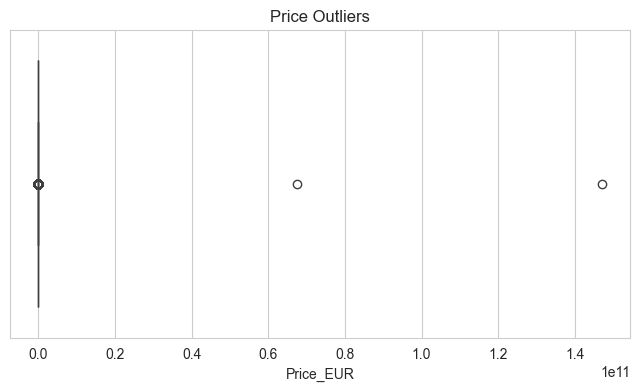

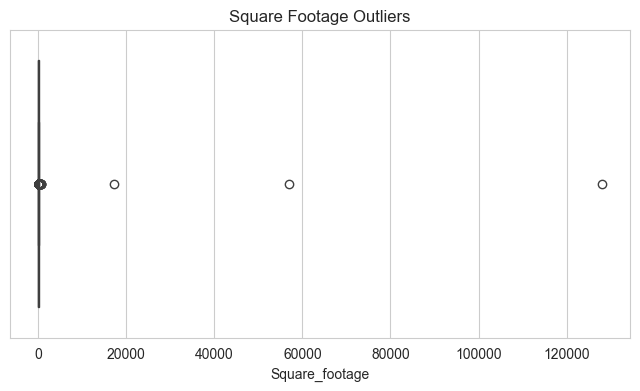

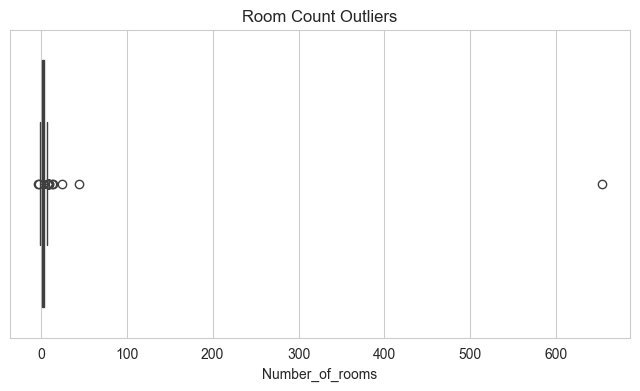

In [77]:
#Checking outliers 
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Price_EUR"])
plt.title("Price Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Square_footage"])
plt.title("Square Footage Outliers")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Number_of_rooms"])
plt.title("Room Count Outliers")
plt.show()

In [78]:
df.sort_values("Price_EUR", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
7811,1.470304e+11,125.00,5.0,U izgradnji,1,Centralno grejanje,1,1,7,Vukov spomenik
8422,6.760032e+10,65.29,2.0,U izgradnji,1,Etažno grejanje na gas,0,0,1,Čukarica
7546,4.250450e+07,46.35,2.0,Novogradnja,1,Centralno grejanje,1,1,0,Savski venac
6510,2.023312e+07,49.05,2.0,U izgradnji,1,Centralno grejanje,0,0,4,Voždovac
8936,7.834992e+06,215.84,5.0,Novogradnja,0,Centralno grejanje,0,0,9,Tošin bunar
7438,5.000000e+06,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
8932,4.234782e+06,118.29,4.0,Novogradnja,0,Centralno grejanje,0,0,10,Tošin bunar
8912,4.122756e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,6,Tošin bunar
8900,4.063521e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,5,Tošin bunar
8913,4.004286e+06,118.47,4.0,Novogradnja,0,Centralno grejanje,0,0,4,Tošin bunar


In [79]:
df.sort_values("Square_footage", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
8538,455000.0,128000.00,5.0,Delimična rekonstrukcija,1,Centralno grejanje,0,0,2,Bežanijska kosa II
1967,205000.0,57000.00,3.0,Lux,0,"Podno grejanje, Kamin",0,1,Prizemlje,Zemun (Gardoš)
9414,2250000.0,17300.00,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
9136,800000.0,650.00,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
133,1500000.0,630.00,4.0,Novogradnja,1,Centralno grejanje,1,1,3,Dedinje (RTV Pink)
9039,285000.0,607.00,6.0,Standardna gradnja,0,Ostalo,0,0,2,Barajevo
9574,1400000.0,541.00,8.0,Standardna gradnja,0,"Klima uređaj, Ostalo",0,0,2,Dedinje (RTV Pink)
7438,5000000.0,453.19,5.0,Novogradnja,1,"Centralno grejanje, Klima uređaj",0,1,39,Novi Beograd Blok 65
9600,970000.0,450.00,5.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,1,7,Vračar (Centar)
5913,600000.0,420.00,2.0,Standardna gradnja,1,Centralno grejanje,0,0,6,Višnjica


In [80]:
df.sort_values("Number_of_rooms", ascending=False).head(10)

,Price_EUR,Square_footage,Number_of_rooms,State,Lift,Heating,Optical_internet,Parking,Floor,Street
9414,2250000.0,17300.0,653.0,Standardna gradnja,0,Ostalo,0,0,0,Galenika
4966,98900.0,44.0,44.0,Lux,0,Etažno grejanje na struju,1,1,Prizemlje,Ledine
9136,800000.0,650.0,25.0,Novogradnja,0,Etažno grejanje na struju,0,1,Prizemlje,Sopot
9522,1100000.0,369.0,14.0,Izvorno stanje,1,"Klima uređaj, Etažno grejanje na struju, Etažn...",1,1,3,Dedinje (Beli dvor)
3864,195000.0,107.0,13.0,Standardna gradnja,0,Etažno grejanje na struju,0,0,1,Banjica
6560,850000.0,310.0,10.0,Standardna gradnja,0,Centralno grejanje,0,0,5,Trg Republike ( centar )
2334,90000.0,62.0,10.0,Standardna gradnja,0,TA peć,0,0,1,Sremčica
3986,1390000.0,205.0,9.0,Standardna gradnja,1,Centralno grejanje,0,0,4,Knez Mihailova ( centar )
5890,491550.0,226.0,9.0,Novogradnja,0,Centralno grejanje,0,0,0,Ledine
4870,990000.0,239.0,9.0,Standardna gradnja,0,"Centralno grejanje, Klima uređaj",0,0,1,Kalemegdan


In [81]:
# droping extreme outliers
df = df[(df["Square_footage"] >= 15) & (df["Square_footage"] <= 400)]
df = df[(df["Number_of_rooms"] > 0) & (df["Number_of_rooms"] <= 10)]

In [82]:
min_price = 20000
max_price = 2000000
df = df[(df["Price_EUR"] >= min_price) & (df["Price_EUR"] <= max_price)]

In [83]:
# Create price per m2 feature
df["price_per_m2"] = df["Price_EUR"] / df["Square_footage"]

# Drop apartments where price_per_m2 > 11,000
df = df[df["price_per_m2"] <= 11000]

# Check the new dataset
print(df.describe())

          Price_EUR  Square_footage  Number_of_rooms         Lift  \
count  9.489000e+03     9489.000000      9489.000000  9489.000000   
mean   2.865833e+05       81.735410         2.918274     0.521973   
std    2.212040e+05       44.905538         1.129634     0.499543   
min    2.100000e+04       15.000000         0.500000     0.000000   
25%    1.500000e+05       53.000000         2.000000     0.000000   
50%    2.295000e+05       70.000000         3.000000     1.000000   
75%    3.400000e+05       98.340000         4.000000     1.000000   
max    2.000000e+06      400.000000        10.000000     1.000000   

       Optical_internet      Parking  price_per_m2  
count       9489.000000  9489.000000   9489.000000  
mean           0.063231     0.289072   3428.187752  
std            0.243391     0.453355   1288.317969  
min            0.000000     0.000000    399.103139  
25%            0.000000     0.000000   2545.454545  
50%            0.000000     0.000000   3250.000000  
75%    

In [84]:
#dropping outliers for small apartments with large amount of rooms
df.loc[df["Square_footage"] < 70, "Number_of_rooms"] = df.loc[df["Square_footage"] < 70, "Number_of_rooms"].clip(upper=4)

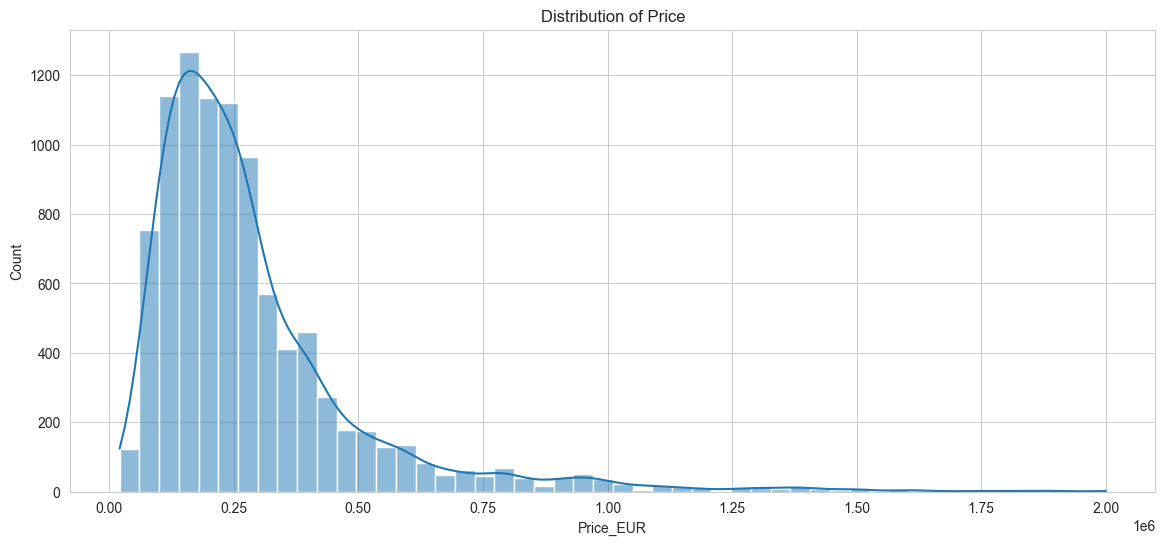

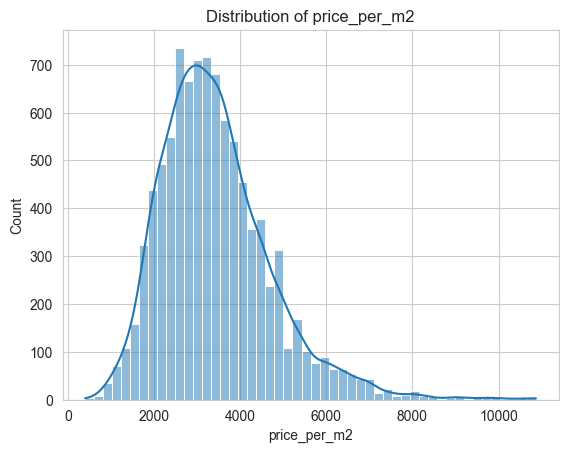

In [85]:
plt.figure(figsize=(14,6))
sns.histplot(df["Price_EUR"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

sns.histplot(df["price_per_m2"], bins=50, kde=True)
plt.title("Distribution of price_per_m2")
plt.show()

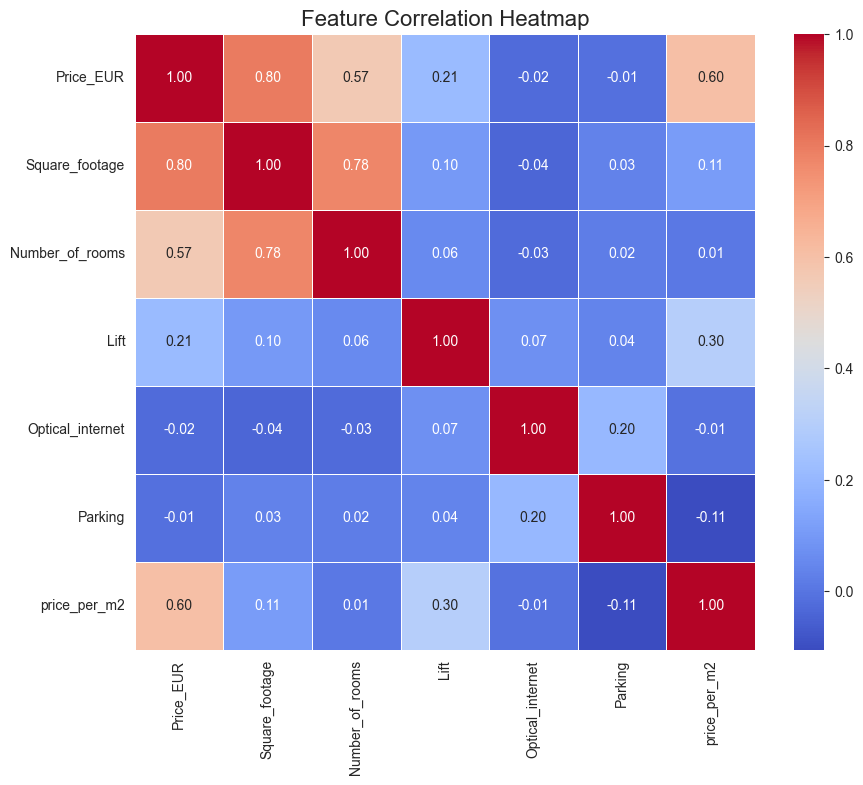

In [86]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

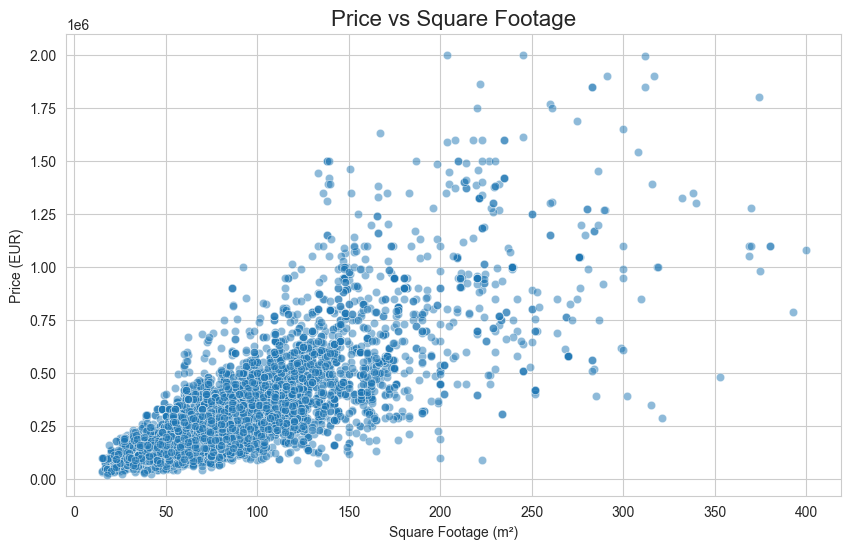

In [87]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Square_footage",
    y="Price_EUR",
    data=df,
    alpha=0.5
)

plt.title("Price vs Square Footage", fontsize=16)
plt.xlabel("Square Footage (m²)")
plt.ylabel("Price (EUR)")
plt.show()

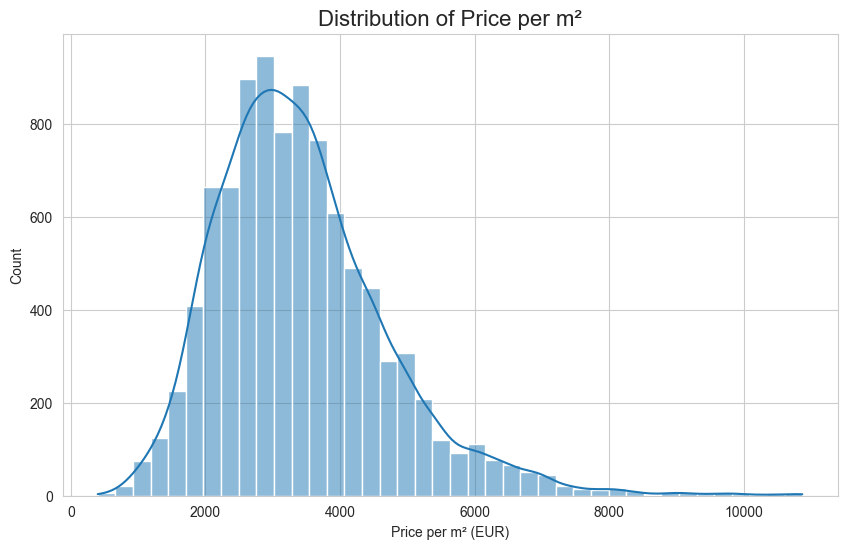

In [88]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_per_m2"],
    bins=40,
    kde=True
)

plt.title("Distribution of Price per m²", fontsize=16)
plt.xlabel("Price per m² (EUR)")
plt.show()

In [89]:
df["State"].unique()

<StringArray>
[      'Standardna gradnja',           'Izvorno stanje',
              'Novogradnja',                      'Lux',
 'Kompletna rekonstrukcija',              'U izgradnji',
       'Završena izgradnja', 'Delimična rekonstrukcija',
               'U pripremi']
Length: 9, dtype: str

In [90]:
df["Heating"].unique()

<StringArray>
[                                                                                                                                   'Centralno grejanje',
                                                                                                                      'Centralno grejanje, Klima uređaj',
                                                                                                                                'Etažno grejanje na gas',
                                                                                                                                                'Ostalo',
                                                                                                                                        'Toplotna pumpa',
                                                                                                               'Klima uređaj, Etažno grejanje na struju',
                                                              

In [91]:
df["Street"].unique()

<StringArray>
[                                  'Žarkovo',
                              'Miljakovac I',
                                 'Karaburma',
                                  'Zvezdara',
                                   'Krnjača',
                               'Medaković I',
                           'Vračar (Centar)',
               'Novi Beograd Blok 12 (YUBC)',
                               'Autokomanda',
                                  'Voždovac',
 ...
                                'Ostružnica',
                              'Medak padina',
                                   'Trešnja',
                             'Gradic Pejton',
                     'Novi Beograd Blok 11b',
                                     'Avala',
                               'Jabučki rit',
                          'Zemun (Sutjeska)',
                                     'Makiš',
 'Novi Beograd Blok 16 (Ušće šoping centar)']
Length: 256, dtype: str

In [92]:
#Categorize the state feature
state_map = {
    "Novogradnja": "New",
    "U izgradnji": "New",
    "Završena izgradnja": "New",
    "U pripremi": "New",

    "Standardna gradnja": "Standard",

    "Izvorno stanje": "Needs_renovation",

    "Kompletna rekonstrukcija": "Renovated",
    "Delimična rekonstrukcija": "Renovated",

    "Lux": "Luxury"
}

df["State"] = df["State"].map(state_map)

In [93]:
# Heating categorization
heating_types = [
    "Centralno grejanje",
    "Etažno grejanje na gas",
    "Etažno grejanje na struju",
    "Etažno grejanje na čvrsto gorivo",
    "Podno grejanje",
    "Toplotna pumpa",
    "TA peć",
    "Kamin",
    "Peć na drva/ugalj",
    "Klima uređaj"
]

for heating in heating_types:
    df[f"heating_{heating}"] = df["Heating"].str.contains(heating, na=False).astype(int)

df.drop(columns=["Heating"], inplace=True)

In [94]:
df = add_geo_features(
    df,
    location_col="Street",
    cache_path=Path("geo_cache.csv"),
    user_agent="belgrade_real_estate_model",
    city_hint="Belgrade",
    country_hint="Serbia",
    delay_seconds=1,
    center_lat=44.8167,
    center_lon=20.4600
)

In [95]:
# fix broken coordinates
df = df[
    (df["lat"].between(44.6, 45.0)) &
    (df["lon"].between(20.2, 20.7))
]

In [96]:
# drop this column since its not neccessary(0 missing after droping)
df = df.drop(columns=["geo_missing"])


<Axes: xlabel='dist_to_center_km', ylabel='Price_EUR'>

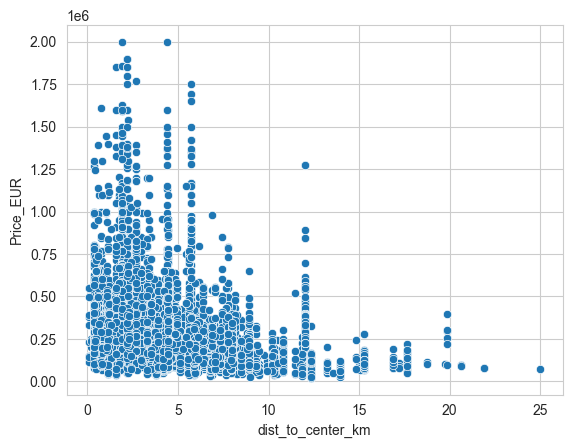

In [97]:
sns.scatterplot(x="dist_to_center_km", y="Price_EUR", data=df)

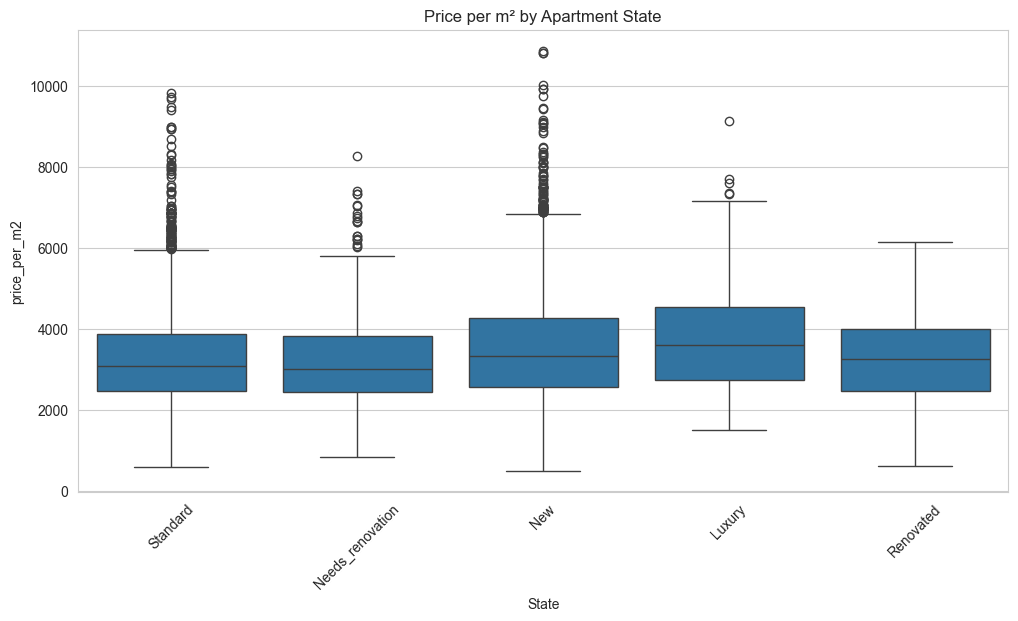

In [98]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="State", y="price_per_m2")
plt.xticks(rotation=45)
plt.title("Price per m² by Apartment State")
plt.show()

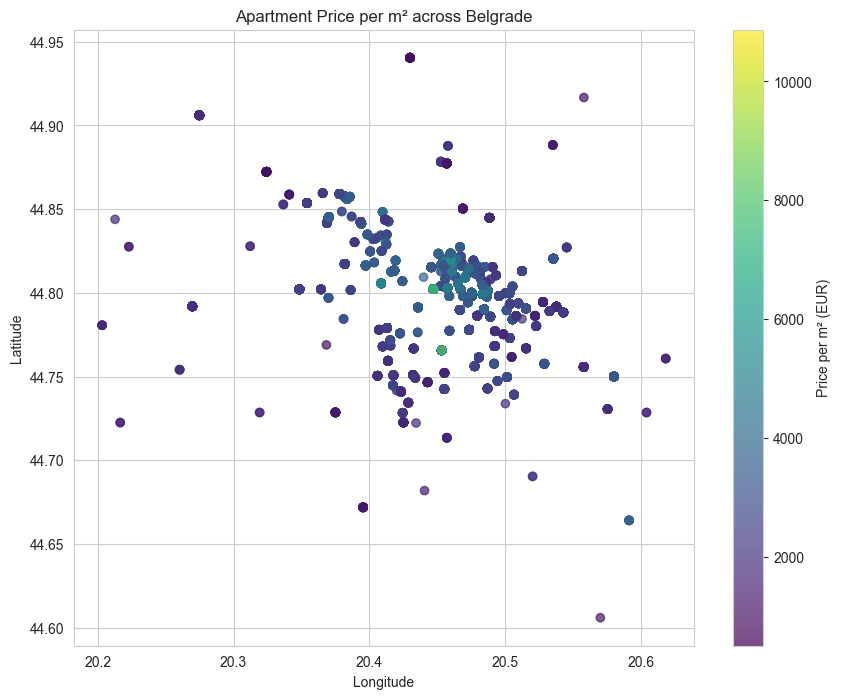

In [99]:

plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["price_per_m2"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Price per m² (EUR)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Apartment Price per m² across Belgrade")

plt.show()

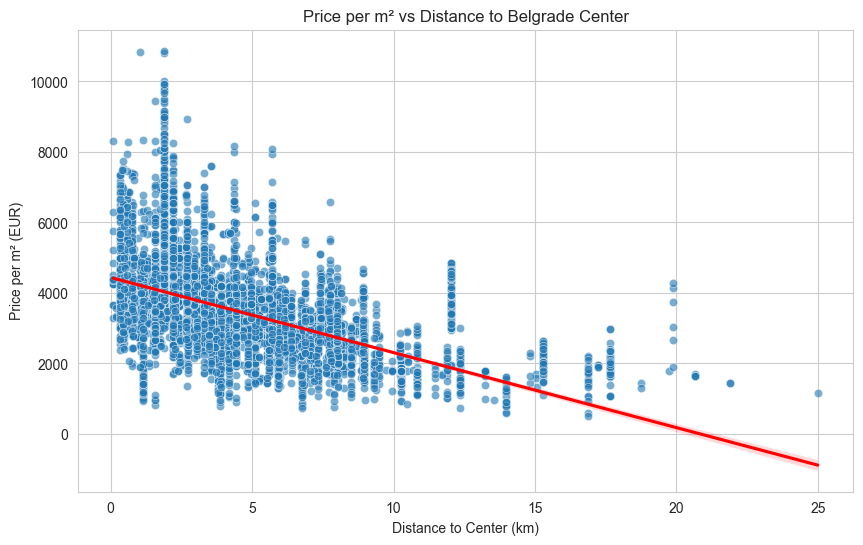

In [100]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="dist_to_center_km",
    y="price_per_m2",
    scatter=False,
    color="red"
)

plt.title("Price per m² vs Distance to Belgrade Center")
plt.xlabel("Distance to Center (km)")
plt.ylabel("Price per m² (EUR)")

plt.show()

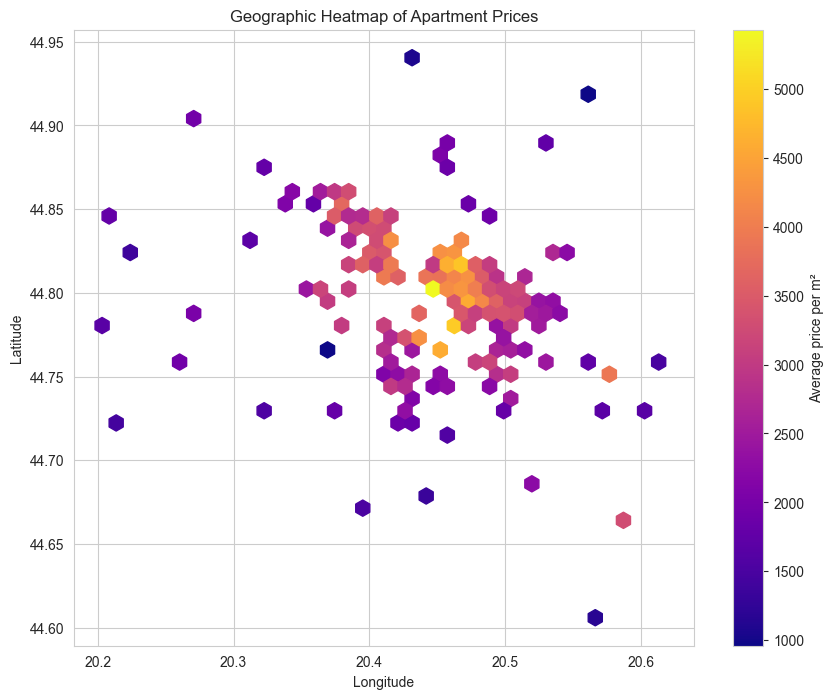

In [101]:
plt.figure(figsize=(10,8))

plt.hexbin(
    df["lon"],
    df["lat"],
    C=df["price_per_m2"],
    gridsize=40,
    cmap="plasma"
)

plt.colorbar(label="Average price per m²")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Heatmap of Apartment Prices")

plt.show()

In [102]:
print(df.columns)

Index(['Price_EUR', 'Square_footage', 'Number_of_rooms', 'State', 'Lift',
       'Optical_internet', 'Parking', 'Floor', 'Street', 'price_per_m2',
       'heating_Centralno grejanje', 'heating_Etažno grejanje na gas',
       'heating_Etažno grejanje na struju',
       'heating_Etažno grejanje na čvrsto gorivo', 'heating_Podno grejanje',
       'heating_Toplotna pumpa', 'heating_TA peć', 'heating_Kamin',
       'heating_Peć na drva/ugalj', 'heating_Klima uređaj', 'lat', 'lon',
       'geo_status', 'dist_to_center_km'],
      dtype='str')


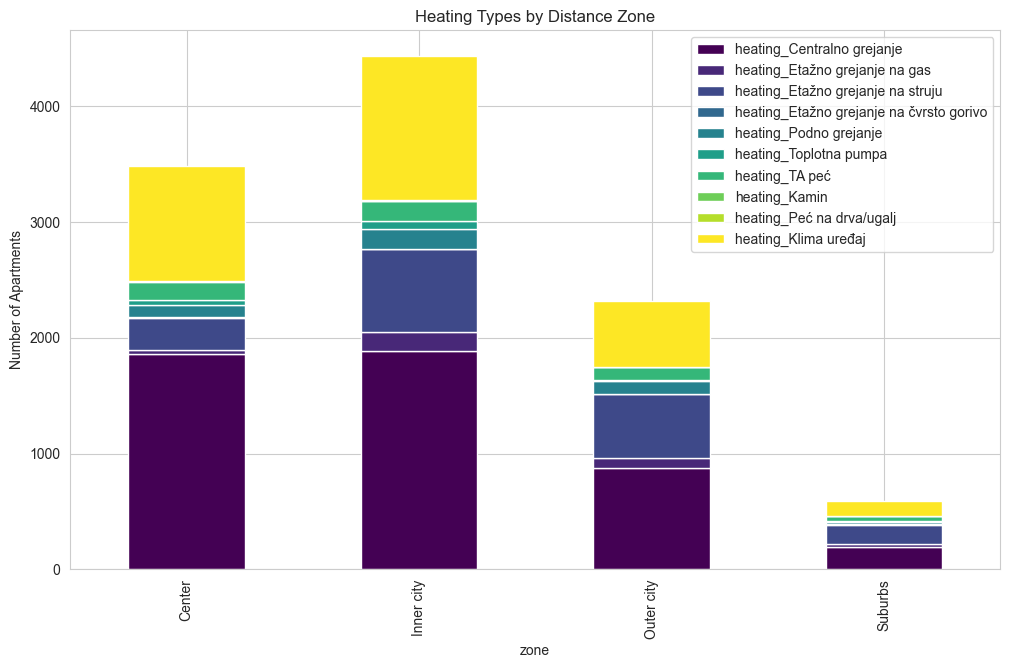

In [103]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
)

heating_cols = [c for c in df.columns if c.startswith("heating_")]

heating_zone = df.groupby("zone")[heating_cols].sum()

heating_zone.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7),
    colormap="viridis"
)

plt.title("Heating Types by Distance Zone")
plt.ylabel("Number of Apartments")

plt.show()

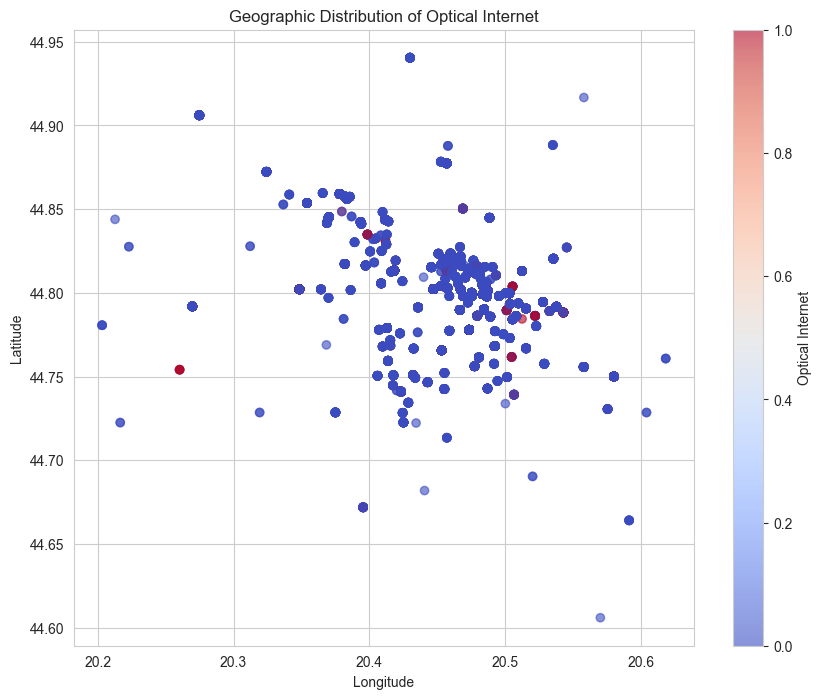

In [104]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["Optical_internet"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="Optical Internet")
plt.title("Geographic Distribution of Optical Internet")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [105]:
print(df[["dist_to_center_km","Optical_internet"]].corr())

                   dist_to_center_km  Optical_internet
dist_to_center_km           1.000000          0.040404
Optical_internet            0.040404          1.000000


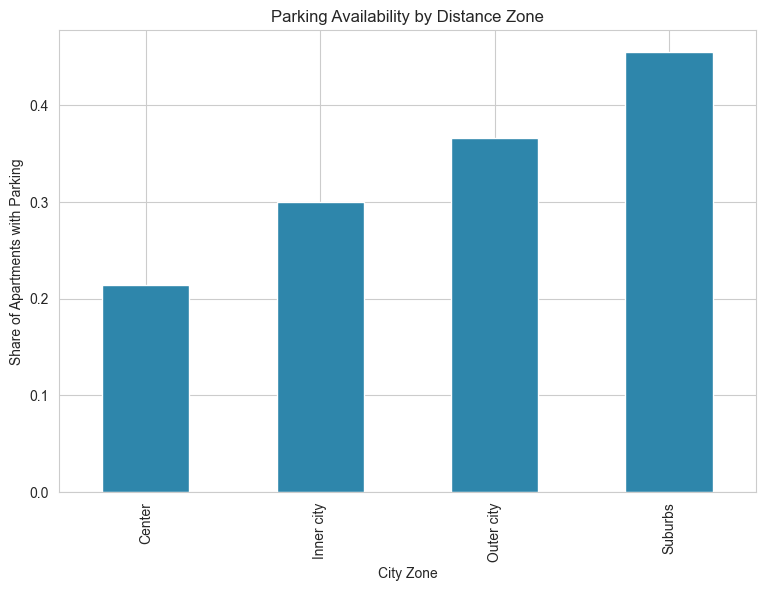

In [106]:
df["zone"] = pd.cut(
    df["dist_to_center_km"],
    bins=[0,3,6,10,25],
    labels=["Center","Inner city","Outer city","Suburbs"]
) 

parking_zone = df.groupby("zone")["Parking"].mean()

plt.figure(figsize=(9,6))

parking_zone.plot(
    kind="bar",
    color="#2E86AB"
)

plt.title("Parking Availability by Distance Zone")
plt.ylabel("Share of Apartments with Parking")
plt.xlabel("City Zone")

plt.show()

C:\Users\Srky\AppData\Local\Temp\ipykernel_16968\1255840651.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


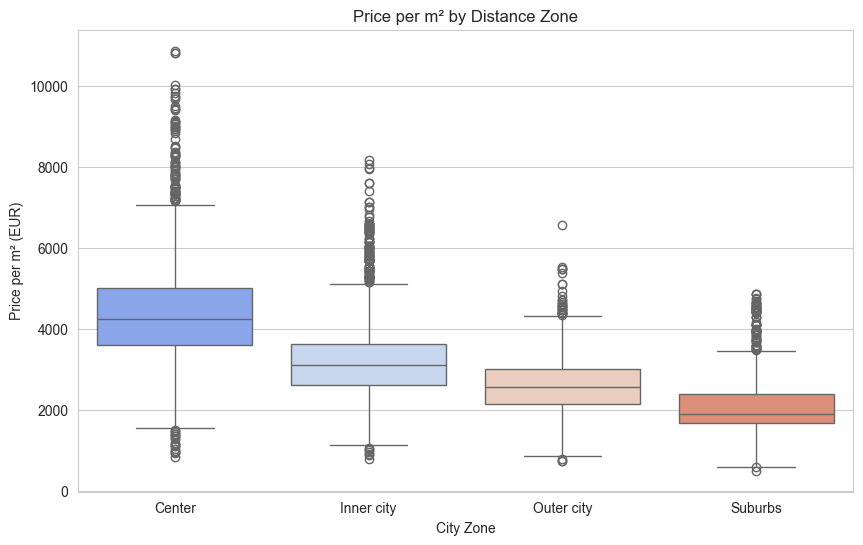

In [107]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="zone",
    y="price_per_m2",
    palette="coolwarm"
)

plt.title("Price per m² by Distance Zone")
plt.ylabel("Price per m² (EUR)")
plt.xlabel("City Zone")

plt.show()

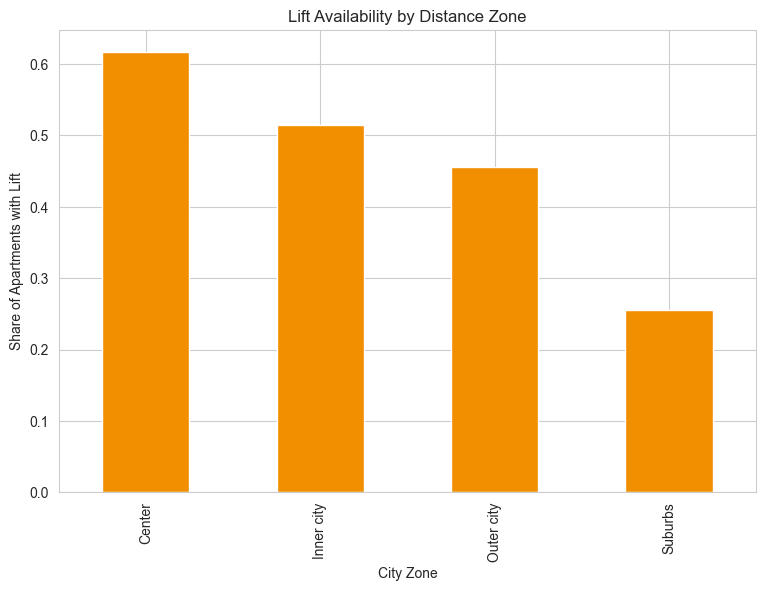

In [108]:
lift_zone = df.groupby("zone")["Lift"].mean()

plt.figure(figsize=(9,6))

lift_zone.plot(
    kind="bar",
    color="#F18F01"
)

plt.title("Lift Availability by Distance Zone")
plt.ylabel("Share of Apartments with Lift")
plt.xlabel("City Zone")

plt.show()

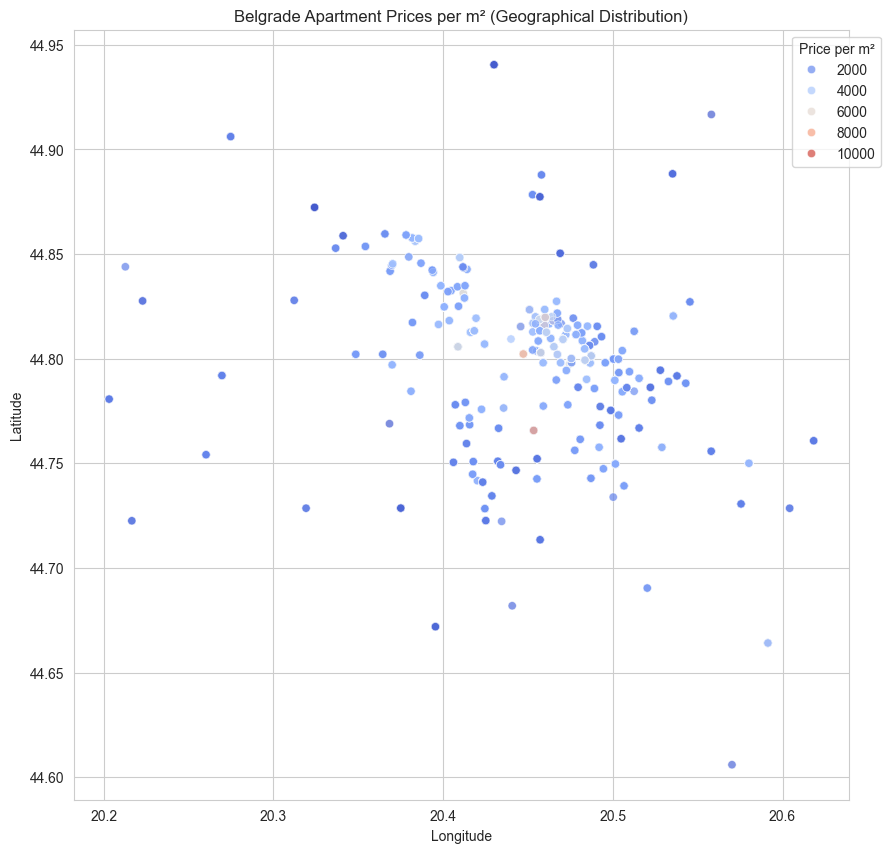

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

sns.scatterplot(
    data=df,
    x="lon",
    y="lat",
    hue="price_per_m2",
    palette="coolwarm",
    alpha=0.7
)

plt.title("Belgrade Apartment Prices per m² (Geographical Distribution)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Price per m²", bbox_to_anchor=(1.05,1))

plt.show()

In [110]:
df.info()

<class 'pandas.DataFrame'>
Index: 8804 entries, 0 to 9617
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   Price_EUR                                 8804 non-null   float64 
 1   Square_footage                            8804 non-null   float64 
 2   Number_of_rooms                           8804 non-null   float64 
 3   State                                     8804 non-null   str     
 4   Lift                                      8804 non-null   int64   
 5   Optical_internet                          8804 non-null   int64   
 6   Parking                                   8804 non-null   int64   
 7   Floor                                     8804 non-null   str     
 8   Street                                    8804 non-null   str     
 9   price_per_m2                              8804 non-null   float64 
 10  heating_Centralno grejanje              

In [111]:
print(df["Floor"].unique())
# Mapping special floor names to numbers
floor_mapping = {
    "Suteren": -1,
    "Prizemlje": 0,
    "Visoko prizemlje": 0.5
}

# Replace mapped values
df["Floor"] = df["Floor"].replace(floor_mapping)

# Convert the rest to float
df["Floor"] = df["Floor"].astype(float)

<StringArray>
[               '0',                '4',                '3',
                '2',                '1',                '5',
                '7',                '6',                '9',
          'Suteren',        'Prizemlje',               '14',
 'Visoko prizemlje',               '20',               '13',
               '15',               '12',               '10',
                '8',               '23',               '22',
               '19',               '11',               '40',
               '21',               '27',               '30',
               '16',               '18',               '26',
               '24',               '-1',               '17',
               '29',               '28',               '36',
               '34',               '33',               '25']
Length: 39, dtype: str


In [112]:
# FEATURES / TARGET

X = df.drop(columns=["Price_EUR", "Street", "zone", "geo_status", "price_per_m2"])
y = df["Price_EUR"]

categorical_cols = ["State"]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

In [113]:
# TRAIN / VALIDATION / TEST SPLIT
# 64% train / 16% val / 20% test

from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (5634, 20) (5634,)
Val:   (1409, 20) (1409,)
Test:  (1761, 20) (1761,)


In [114]:
# HELPERS FOR EVALUATION

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def evaluate_model(model_name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    preds = {
        "train": model.predict(X_train),
        "val": model.predict(X_val),
        "test": model.predict(X_test)
    }

    rows = []
    for split_name, y_true in [("train", y_train), ("val", y_val), ("test", y_test)]:
        m = regression_metrics(y_true, preds[split_name])
        rows.append({
            "model": model_name,
            "split": split_name,
            **m
        })

    return pd.DataFrame(rows)

def overfit_gap(summary_df):
    wide = summary_df.pivot(index="model", columns="split", values="R2").reset_index()
    wide["gap_train_val"] = wide["train"] - wide["val"]
    wide["gap_train_test"] = wide["train"] - wide["test"]
    return wide

In [115]:
# PREPROCESSORS

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [116]:
# BASE MODELS

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("regressor", LinearRegression())
])

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_tree),
    ("regressor", XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

In [117]:
# EVALUATE BASE MODELS

results = []

for name, model in [
    ("Linear Regression", lr_pipeline),
    ("Decision Tree", dt_pipeline),
    ("Random Forest", rf_pipeline),
    ("XGBoost", xgb_pipeline)
]:
    res = evaluate_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test)
    results.append(res)

results_df = pd.concat(results, ignore_index=True)
print(results_df)

summary_df = overfit_gap(results_df)
print(summary_df)

                model  split           MAE           RMSE        R2
0   Linear Regression  train  69367.954907  115144.855504  0.732848
1   Linear Regression    val  71983.744607  117351.869257  0.712499
2   Linear Regression   test  63219.768790   97680.786554  0.761011
3       Decision Tree  train  42817.082397   67705.809193  0.907632
4       Decision Tree    val  57052.143335   98603.480628  0.797024
5       Decision Tree   test  51895.617789   88042.777268  0.805846
6       Random Forest  train  15407.454970   28854.184882  0.983224
7       Random Forest    val  44470.842179   83015.068579  0.856129
8       Random Forest   test  39845.905805   76018.263758  0.855258
9             XGBoost  train  20793.970268   31975.467184  0.979398
10            XGBoost    val  44104.379409   83443.333987  0.854641
11            XGBoost   test  39396.383499   73879.883247  0.863286
split              model      test     train       val  gap_train_val  \
0          Decision Tree  0.805846  0.90763

In [118]:
# OPTIMIZED DECISION TREE

from sklearn.model_selection import RandomizedSearchCV

dt_param_dist = {
    "regressor__max_depth": [3, 4, 5, 6, 8, 10, 12, None],
    "regressor__min_samples_split": [2, 5, 10, 15, 20],
    "regressor__min_samples_leaf": [1, 2, 4, 6, 8],
    "regressor__max_features": [None, "sqrt", "log2"],
    "regressor__criterion": ["squared_error", "friedman_mse", "absolute_error"]
}

dt_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("regressor", DecisionTreeRegressor(random_state=42))
    ]),
    param_distributions=dt_param_dist,
    n_iter=30,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

dt_search.fit(X_train, y_train)

print("Best Decision Tree params:", dt_search.best_params_)

dt_best = dt_search.best_estimator_

dt_opt_results = evaluate_model(
    "Decision Tree (Optimized)",
    dt_best,
    X_train, y_train, X_val, y_val, X_test, y_test
)

results_df = pd.concat([results_df, dt_opt_results], ignore_index=True)
print(results_df)

summary_df = overfit_gap(results_df)
print(summary_df)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Decision Tree params: {'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 8, 'regressor__max_features': None, 'regressor__max_depth': 8, 'regressor__criterion': 'squared_error'}
                        model  split           MAE           RMSE        R2
0           Linear Regression  train  69367.954907  115144.855504  0.732848
1           Linear Regression    val  71983.744607  117351.869257  0.712499
2           Linear Regression   test  63219.768790   97680.786554  0.761011
3               Decision Tree  train  42817.082397   67705.809193  0.907632
4               Decision Tree    val  57052.143335   98603.480628  0.797024
5               Decision Tree   test  51895.617789   88042.777268  0.805846
6               Random Forest  train  15407.454970   28854.184882  0.983224
7               Random Forest    val  44470.842179   83015.068579  0.856129
8               Random Forest   test  39845.905805   760

In [119]:
# OPTIMIZED RANDOM FOREST

rf_param_dist = {
    "regressor__n_estimators": [100, 200, 300, 400],
    "regressor__max_depth": [None, 10, 20, 30, 40],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": [None, "sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

print("Best Random Forest params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_

rf_opt_results = evaluate_model(
    "Random Forest (Optimized)",
    rf_best,
    X_train, y_train, X_val, y_val, X_test, y_test
)

results_df = pd.concat([results_df, rf_opt_results], ignore_index=True)
print(results_df)

summary_df = overfit_gap(results_df)
print(summary_df)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Random Forest params: {'regressor__n_estimators': 300, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': None, 'regressor__max_depth': None}
                        model  split           MAE           RMSE        R2
0           Linear Regression  train  69367.954907  115144.855504  0.732848
1           Linear Regression    val  71983.744607  117351.869257  0.712499
2           Linear Regression   test  63219.768790   97680.786554  0.761011
3               Decision Tree  train  42817.082397   67705.809193  0.907632
4               Decision Tree    val  57052.143335   98603.480628  0.797024
5               Decision Tree   test  51895.617789   88042.777268  0.805846
6               Random Forest  train  15407.454970   28854.184882  0.983224
7               Random Forest    val  44470.842179   83015.068579  0.856129
8               Random Forest   test  39845.905805   76018.2637

In [120]:
# OPTIMIZED XGBOOST

xgb_param_dist = {
    "regressor__n_estimators": [200, 300, 400, 500, 600],
    "regressor__max_depth": [4, 5, 6, 7, 8, 10],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1, 0.2],
    "regressor__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__gamma": [0, 0.1, 0.2, 0.3],
    "regressor__reg_alpha": [0, 0.01, 0.1, 1],
    "regressor__reg_lambda": [1, 1.5, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("regressor", XGBRegressor(
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        ))
    ]),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost params:", xgb_search.best_params_)

xgb_best = xgb_search.best_estimator_

xgb_opt_results = evaluate_model(
    "XGBoost (Optimized)",
    xgb_best,
    X_train, y_train, X_val, y_val, X_test, y_test
)

results_df = pd.concat([results_df, xgb_opt_results], ignore_index=True)
print(results_df)

summary_df = overfit_gap(results_df)
print(summary_df)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best XGBoost params: {'regressor__subsample': 0.6, 'regressor__reg_lambda': 2, 'regressor__reg_alpha': 0.1, 'regressor__n_estimators': 500, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.03, 'regressor__gamma': 0, 'regressor__colsample_bytree': 0.6}
                        model  split           MAE           RMSE        R2
0           Linear Regression  train  69367.954907  115144.855504  0.732848
1           Linear Regression    val  71983.744607  117351.869257  0.712499
2           Linear Regression   test  63219.768790   97680.786554  0.761011
3               Decision Tree  train  42817.082397   67705.809193  0.907632
4               Decision Tree    val  57052.143335   98603.480628  0.797024
5               Decision Tree   test  51895.617789   88042.777268  0.805846
6               Random Forest  train  15407.454970   28854.184882  0.983224
7               Random Forest    val  44470.842179   83015.068579  0.8

In [121]:
# FINAL COMPARISON

final_summary = (
    results_df
    .groupby(["model", "split"], as_index=False)[["MAE", "RMSE", "R2"]]
    .mean()
)

print(final_summary)

r2_table = final_summary.pivot(index="model", columns="split", values="R2")
r2_table["gap_train_val"] = r2_table["train"] - r2_table["val"]
r2_table["gap_train_test"] = r2_table["train"] - r2_table["test"]

print(r2_table.sort_values("val", ascending=False))

                        model  split           MAE           RMSE        R2
0               Decision Tree   test  51895.617789   88042.777268  0.805846
1               Decision Tree  train  42817.082397   67705.809193  0.907632
2               Decision Tree    val  57052.143335   98603.480628  0.797024
3   Decision Tree (Optimized)   test  53281.612332   88483.712990  0.803896
4   Decision Tree (Optimized)  train  47840.598358   77798.087990  0.878043
5   Decision Tree (Optimized)    val  57812.497707   96507.750819  0.805561
6           Linear Regression   test  63219.768790   97680.786554  0.761011
7           Linear Regression  train  69367.954907  115144.855504  0.732848
8           Linear Regression    val  71983.744607  117351.869257  0.712499
9               Random Forest   test  39845.905805   76018.263758  0.855258
10              Random Forest  train  15407.454970   28854.184882  0.983224
11              Random Forest    val  44470.842179   83015.068579  0.856129
12  Random F

                        feature    coefficient       abs_coef
0           num__Square_footage  180601.380201  180601.380201
18       num__dist_to_center_km  -48947.544320   48947.544320
19            cat__State_Luxury   35777.625986   35777.625986
20  cat__State_Needs_renovation  -23239.649277   23239.649277
1          num__Number_of_rooms  -20594.196676   20594.196676
5                    num__Floor   19056.785507   19056.785507
21               cat__State_New   18410.918636   18410.918636
23          cat__State_Standard  -16794.801737   16794.801737
22         cat__State_Renovated  -14154.093608   14154.093608
17                     num__lon  -13421.717126   13421.717126


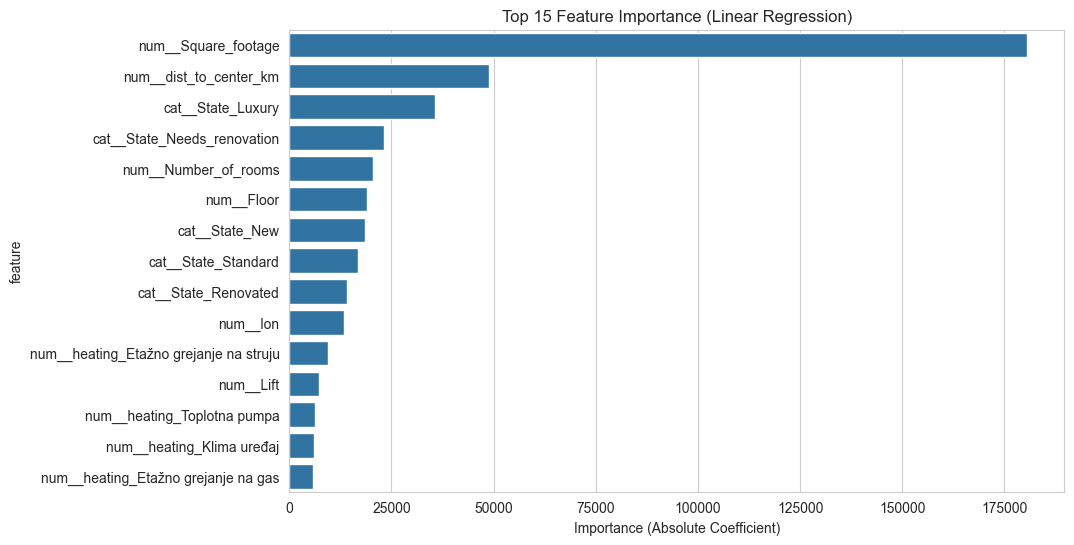

In [122]:
# Linear Regression feature importance
feature_names_lr = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients_lr = lr_pipeline.named_steps["regressor"].coef_

feat_imp_lr = pd.DataFrame({
    "feature": feature_names_lr,
    "coefficient": coefficients_lr
})
feat_imp_lr["abs_coef"] = feat_imp_lr["coefficient"].abs()
feat_imp_lr = feat_imp_lr.sort_values(by="abs_coef", ascending=False)

print(feat_imp_lr.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_lr.head(15), x="abs_coef", y="feature")
plt.title("Top 15 Feature Importance (Linear Regression)")
plt.xlabel("Importance (Absolute Coefficient)")
plt.show()

                              feature  importance
5                      Square_footage    0.775542
23                  dist_to_center_km    0.129715
10                              Floor    0.028353
21                                lat    0.027573
22                                lon    0.014755
13  heating_Etažno grejanje na struju    0.006624
7                                Lift    0.005506
6                     Number_of_rooms    0.005452
2                           State_New    0.004743
11         heating_Centralno grejanje    0.001006


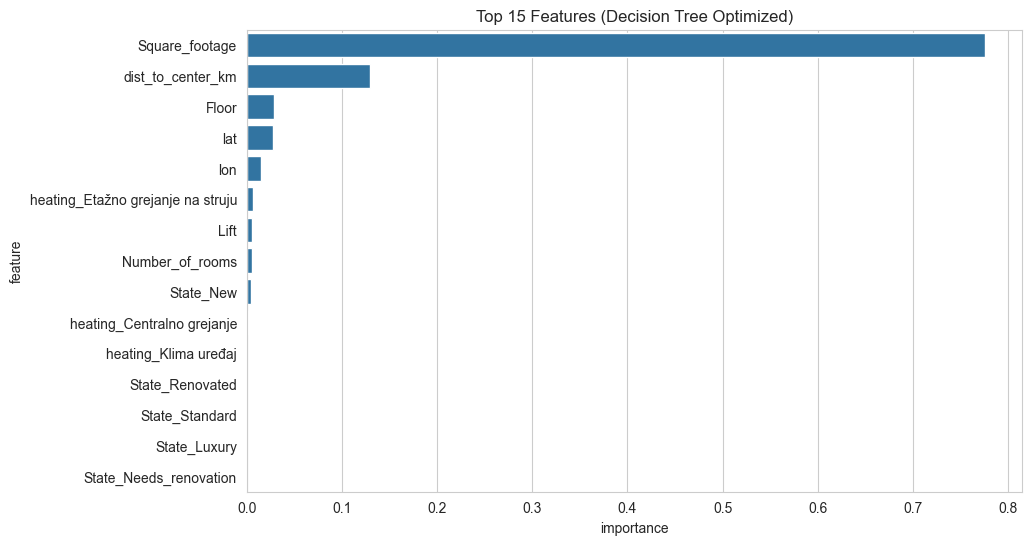

In [123]:
def get_feature_names(preprocessor, numerical_cols, categorical_cols):
    cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
    return np.concatenate([cat_features, numerical_cols])

feature_names_dt = get_feature_names(
    dt_best.named_steps["preprocessor"],
    numerical_cols,
    categorical_cols
)

importances_dt = dt_best.named_steps["regressor"].feature_importances_

feat_imp_dt = pd.DataFrame({
    "feature": feature_names_dt,
    "importance": importances_dt
}).sort_values(by="importance", ascending=False)

print(feat_imp_dt.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_dt.head(15), x="importance", y="feature")
plt.title("Top 15 Features (Decision Tree Optimized)")
plt.show()

                       feature  importance
5               Square_footage    0.710407
23           dist_to_center_km    0.126026
10                       Floor    0.042240
21                         lat    0.033665
22                         lon    0.031057
6              Number_of_rooms    0.014796
7                         Lift    0.009379
2                    State_New    0.005613
11  heating_Centralno grejanje    0.004184
20        heating_Klima uređaj    0.003778


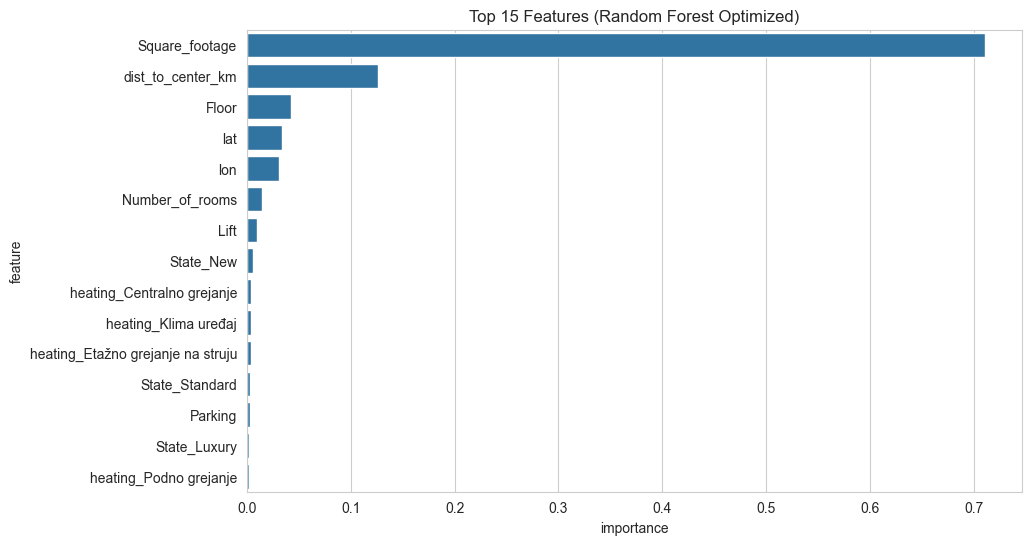

In [124]:
feature_names_rf = get_feature_names(
    rf_best.named_steps["preprocessor"],
    numerical_cols,
    categorical_cols
)

importances_rf = rf_best.named_steps["regressor"].feature_importances_

feat_imp_rf = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values(by="importance", ascending=False)

print(feat_imp_rf.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_rf.head(15), x="importance", y="feature")
plt.title("Top 15 Features (Random Forest Optimized)")
plt.show()

                   feature  importance
5           Square_footage    0.261962
6          Number_of_rooms    0.111085
23       dist_to_center_km    0.097744
22                     lon    0.076301
21                     lat    0.051028
7                     Lift    0.040180
16  heating_Toplotna pumpa    0.039821
10                   Floor    0.035799
2                State_New    0.031387
17          heating_TA peć    0.029998


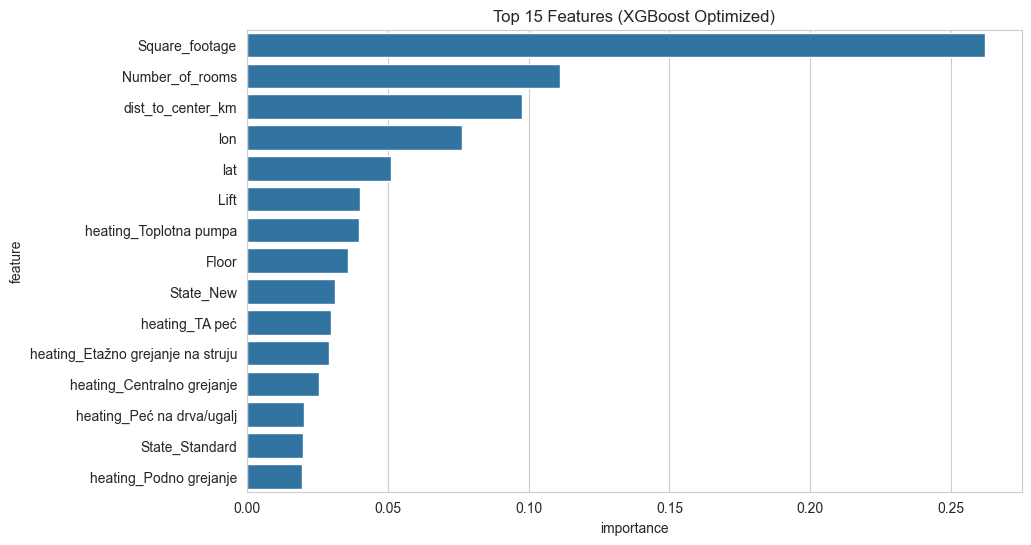

In [125]:
feature_names_xgb = get_feature_names(
    xgb_best.named_steps["preprocessor"],
    numerical_cols,
    categorical_cols
)

importances_xgb = xgb_best.named_steps["regressor"].feature_importances_

feat_imp_xgb = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb
}).sort_values(by="importance", ascending=False)

print(feat_imp_xgb.head(10))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_xgb.head(15), x="importance", y="feature")
plt.title("Top 15 Features (XGBoost Optimized)")
plt.show()

In [126]:
from sklearn.base import clone

# PICK BEST MODEL BY VALIDATION R2
#     AND REFIT ON TRAIN + VAL

# Take the best model according to validation R2
best_model_name = (
    results_df[results_df["split"] == "val"]
    .sort_values("R2", ascending=False)
    .iloc[0]["model"]
)

print("Best model by validation R2:", best_model_name)

# Map model names to fitted estimators
model_map = {
    "Linear Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Decision Tree (Optimized)": dt_best,
    "Random Forest (Optimized)": rf_best,
    "XGBoost (Optimized)": xgb_best
}

best_model = model_map[best_model_name]

# Refit the selected model on train + validation
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_model_refit = clone(best_model)
best_model_refit.fit(X_trainval, y_trainval)

# Final test evaluation after refit
y_pred_best_test = best_model_refit.predict(X_test)

best_test_metrics = regression_metrics(y_test, y_pred_best_test)
print("Final refit model test metrics:")
print(best_test_metrics)

Best model by validation R2: Random Forest (Optimized)
Final refit model test metrics:
{'MAE': np.float64(37969.24638627794), 'RMSE': np.float64(73244.41413308162), 'R2': 0.8656280668944795}


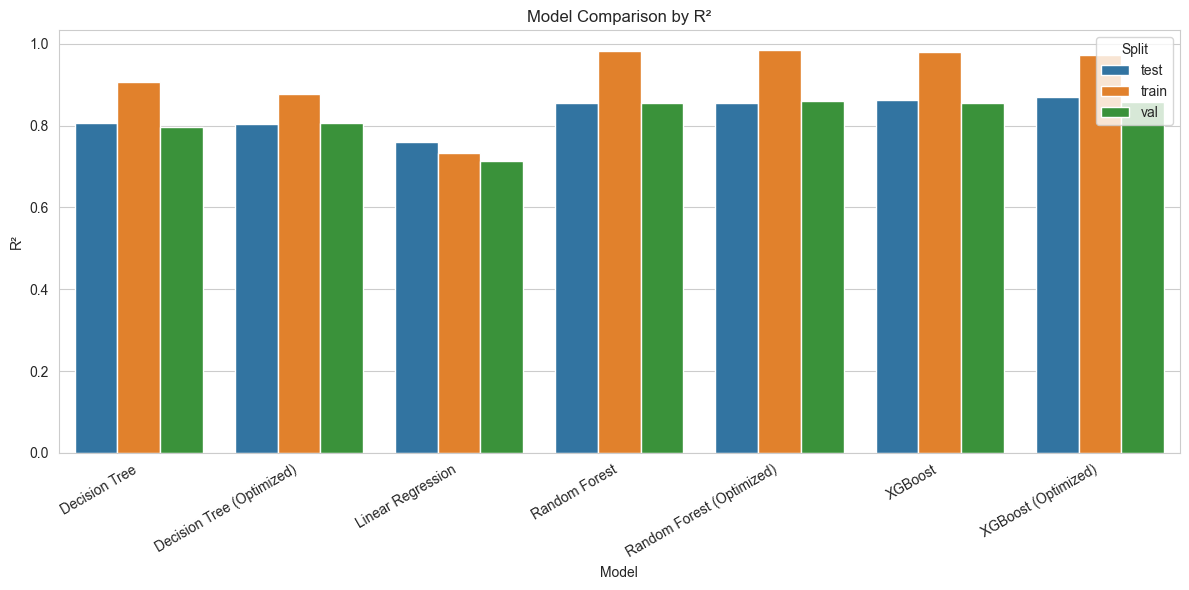

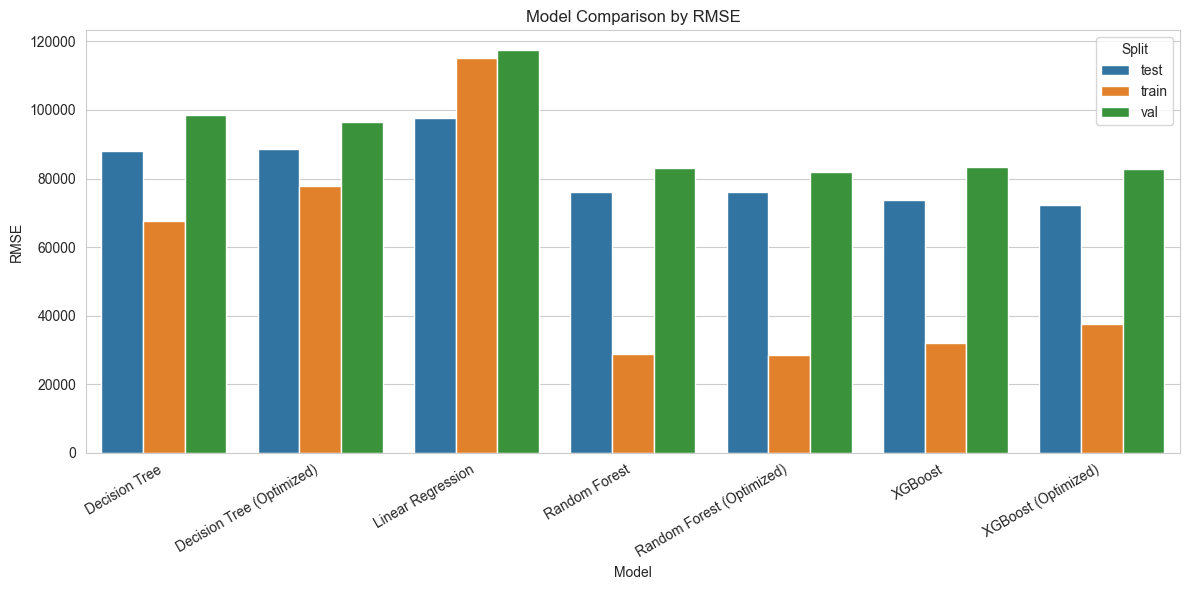

In [127]:
# FINAL MODEL COMPARISON PLOTS

comparison = (
    results_df
    .groupby(["model", "split"], as_index=False)[["R2", "RMSE"]]
    .mean()
)

# --- R2 plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison,
    x="model",
    y="R2",
    hue="split"
)
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

# --- RMSE plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison,
    x="model",
    y="RMSE",
    hue="split"
)
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

In [128]:
print(f"\nBest model: {best_model_name}")
print(f"Test MAE:  {best_test_metrics['MAE']:.2f}")
print(f"Test RMSE: {best_test_metrics['RMSE']:.2f}")
print(f"Test R2:   {best_test_metrics['R2']:.4f}")


Best model: Random Forest (Optimized)
Test MAE:  37969.25
Test RMSE: 73244.41
Test R2:   0.8656


In [129]:
print(
    results_df
    .sort_values(["model", "split"])
    .round(4)
)

                        model  split         MAE         RMSE      R2
5               Decision Tree   test  51895.6178   88042.7773  0.8058
3               Decision Tree  train  42817.0824   67705.8092  0.9076
4               Decision Tree    val  57052.1433   98603.4806  0.7970
14  Decision Tree (Optimized)   test  53281.6123   88483.7130  0.8039
12  Decision Tree (Optimized)  train  47840.5984   77798.0880  0.8780
13  Decision Tree (Optimized)    val  57812.4977   96507.7508  0.8056
2           Linear Regression   test  63219.7688   97680.7866  0.7610
0           Linear Regression  train  69367.9549  115144.8555  0.7328
1           Linear Regression    val  71983.7446  117351.8693  0.7125
8               Random Forest   test  39845.9058   76018.2638  0.8553
6               Random Forest  train  15407.4550   28854.1849  0.9832
7               Random Forest    val  44470.8422   83015.0686  0.8561
17  Random Forest (Optimized)   test  39588.3466   75990.8245  0.8554
15  Random Forest (O